In [1]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import dill

plt.style.use('ggplot')

In [2]:
run_id = 50
names = ['bootstrap_icsmc', 'guided_icsmc', 'reparameterised_icsmc_bs']

icsmc_bootstrap = az.from_netcdf(f'./results/run_{run_id}_bootstrap_icsmc.nc')
icsmc_guided = az.from_netcdf(f'./results/run_{run_id}_guided_icsmc.nc')
icsmc_reparameterised = az.from_netcdf(f'./results/run_{run_id}_reparameterised_icsmc_bs.nc')

with open(f'./results/run_{run_id}_meta.pkl', 'rb') as f:
    metadata = dill.load(f)

idata_dict = {'Boot-iCSMC': icsmc_bootstrap, 'BwG-iCSMC': icsmc_guided, 'BwG-iCSMC-BS': icsmc_reparameterised}

# Unpack the metadata
x, y = metadata['x'], metadata['y']
cdssm = metadata['cdssm']

Nx = icsmc_bootstrap.attrs['Nx']
num = icsmc_bootstrap.attrs['num']
model_sde = icsmc_bootstrap.attrs['model_sde']    
niter = icsmc_bootstrap.attrs['niter']

T = len(y)
S = cdssm.s_ts * T

times = times = np.linspace(start=0., stop=S, num=(num*T + 1))[1:]
obs_times = np.linspace(start=0., stop=S, num=(T+1))[1:]

print(f'Model: {model_sde}, Nx: {Nx}, num: {num}, T={T}, delta_s = {cdssm.s_ts}, S={S}')

Model: IntegratedFitzhughNagumo, Nx: 50, num: 50, T=100, delta_s = 0.05, S=5.0


# The Dataset: this is what we are trying to infer

We present below the FHN model that defines our CD-SSM for this experiment:

\begin{align}
dV_t &= Z_t dt \\
dZ_t &= \frac{1}{\epsilon}(1-\epsilon - 3V_t^2)Z_t dt + \frac{1}{\epsilon}\Big[(1-\gamma)V_t - V_t^3  - (s+\beta)\Big]dt - \frac{\sigma}{\epsilon} dB_t
\end{align}


We have used the following parameter values:

In [3]:
cdssm.params

{'epsilon': 0.1,
 'gamma': 1.5,
 'beta': 0.8,
 'sigma_u': 0.3,
 'G': array([[1., 0.]]),
 'covY': array([[0.0001]])}

We need to resolve the following key problems:
    
- The bridges within the particle filters do not appear to be working properly: look at this and try to diagnose and solve the problem.
- Once you have them working, you may also have issues with the choice of proposal: in particular, the proposal for the ending point might be naive. 
- Finally, you need to optimise the hyperparameters: it should be the case that they are set to reasonable values such that the difference between introducing the transform and not having the transform is clear.

In [4]:
# from cdssm_lib import CDSSM_LIB
# from particles_cdssm.tools import build_cdssm

# cdssm_spec = CDSSM_LIB['ifhn']
# cdssm = build_cdssm(cdssm_spec)

# np.random.seed(3563)

# print('Simulating synthetic data...')
# x, y = cdssm.simulate(T)

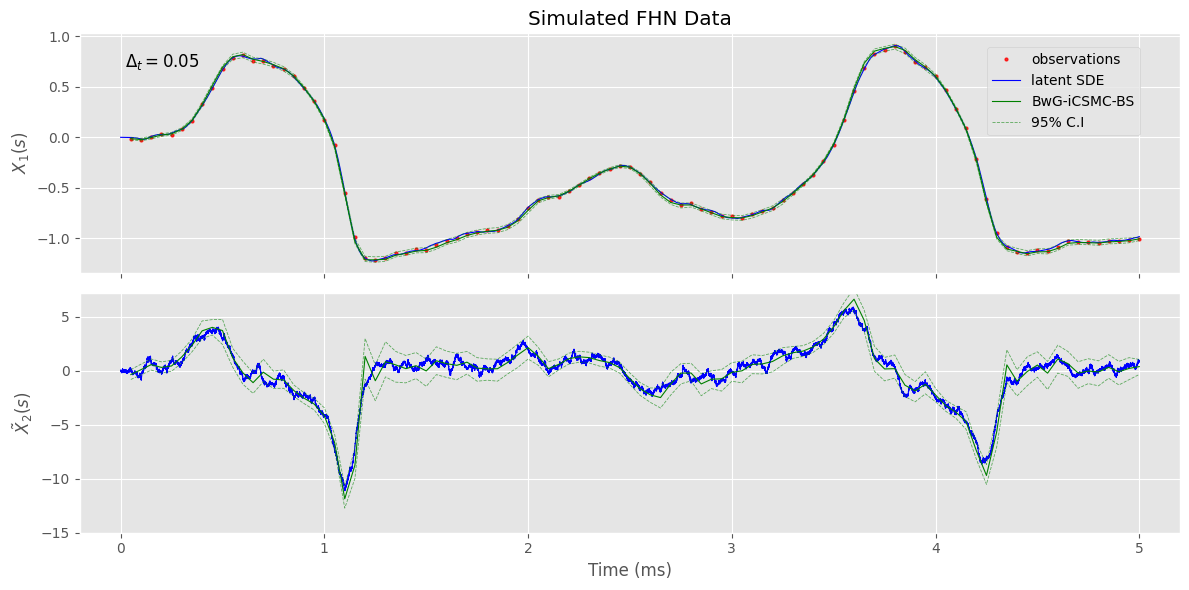

In [ ]:
sde_paths = np.concatenate([np.concatenate([x[i][name] for name in x[0].dtype.names]) for i in range(T)])
sim_times = np.linspace(start=0., stop=S, num=(sde_paths.shape[0] + 1))[1:]

e_ts = np.stack([sde_paths[1000*(i+1) - 1, :] for i in range(T)])
observations = np.array(y).ravel()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
labels = [r'$X_1(s)$', r'$\tilde{X}_2(s)$']

chain_vals = idata_dict['BwG-iCSMC-BS'].posterior['x'].values # (8, 1000, 100, 2)
chain_vals = np.concatenate([chain_vals[i] for i in range(8)], axis=0)
mean_vals = chain_vals.mean(axis=0)
quantile_vals = np.quantile(chain_vals, axis=0, q=[0.05, 0.95])

axes[0].plot(obs_times, observations, 'o', markersize=2.0, color='red', alpha=0.8, label='observations')

for i, ax in enumerate(axes):
    ax.plot(sim_times, sde_paths[:, i], color='blue', linewidth=0.8, linestyle='-', marker=None, label='latent SDE')
    ax.plot(obs_times, mean_vals[:, i], color='green', linewidth=0.8, linestyle='-', marker=None, label='BwG-iCSMC-BS')
    ax.plot(obs_times, quantile_vals[0, :, i], color='green', linewidth=0.6, linestyle='--', marker=None, alpha=0.6, label='95% C.I')
    ax.plot(obs_times, quantile_vals[1, :, i], color='green', linewidth=0.6, linestyle='--', marker=None, alpha=0.6)
    ax.set_ylabel(labels[i])

axes[0].set_title('Simulated FHN Data')
axes[0].text(0.02, 0.7, r'$\Delta_t =$' + f'{cdssm.s_ts}', fontsize=12)
axes[0].legend(loc='upper right', bbox_to_anchor=(0.97, 0.97))

axes[-1].set_xlabel('Time (ms)')
axes[-1].set_xticks([float(i) for i in range(11)])
axes[-1].set_ylim((-15.0, 7.2))

axes[-1].set_xlim((-0.2, 5.2))
# axes[-1].set_ylim((-5.0, 5.0))

plt.tight_layout()
# plt.savefig('fhn_dataset.png', dpi=300)
plt.show()

# Bar Plot of the CPU times

Line2D properties:

- marker, markersize, alpha, linestyle, linewidth, color, markeredgecolor, markerfillcolor.

Patch properties (for bars in barplots, the box in boxplots etc):

- facecolor, alpha, edgecolor,  

We also have to take fillcolor into consideration:

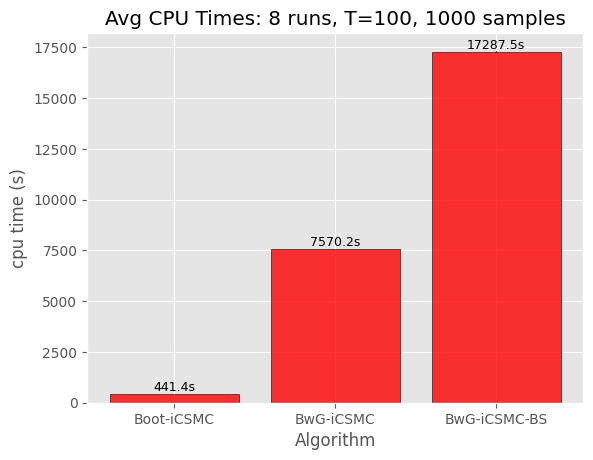

In [31]:
idatas = [icsmc_bootstrap, icsmc_guided, icsmc_reparameterised]
cpu_times = np.stack([idata.attrs['cpu_time'] for idata in idatas], axis=1)

labels = ['Boot-iCSMC', 'BwG-iCSMC', 'BwG-iCSMC-BS']

bar_vals = cpu_times.mean(axis=0)
bar_yerr = np.stack([np.abs(bar_vals - cpu_times.min(axis=0)), np.abs(cpu_times.max(axis=0) - bar_vals)], axis=0)

positions = [i+1 for i in range(3)]

fig, ax = plt.subplots(1, 1)

container = ax.bar(positions, bar_vals, bottom=0., width=0.8, facecolor='red', edgecolor='black', alpha=0.8)
ax.bar_label(container, fmt = lambda x: str(round(x, 1)) + 's', label_type='edge', padding=0., fontsize=9)
ax.errorbar(positions, bar_vals, fmt='none', yerr=bar_yerr, ecolor='black', elinewidth=1.)
ax.set(xlabel='Algorithm', ylabel='cpu time (s)', xticks=positions, xticklabels=labels, title=f'Avg CPU Times: 8 runs, T={T}, {niter} samples')

plt.show()

# Traceplots and KDE Plots

- The BwG-iCSMC-BS algorithm successfully targets the action potential.
- However, in the second spike, the algorithm appears to be off target.

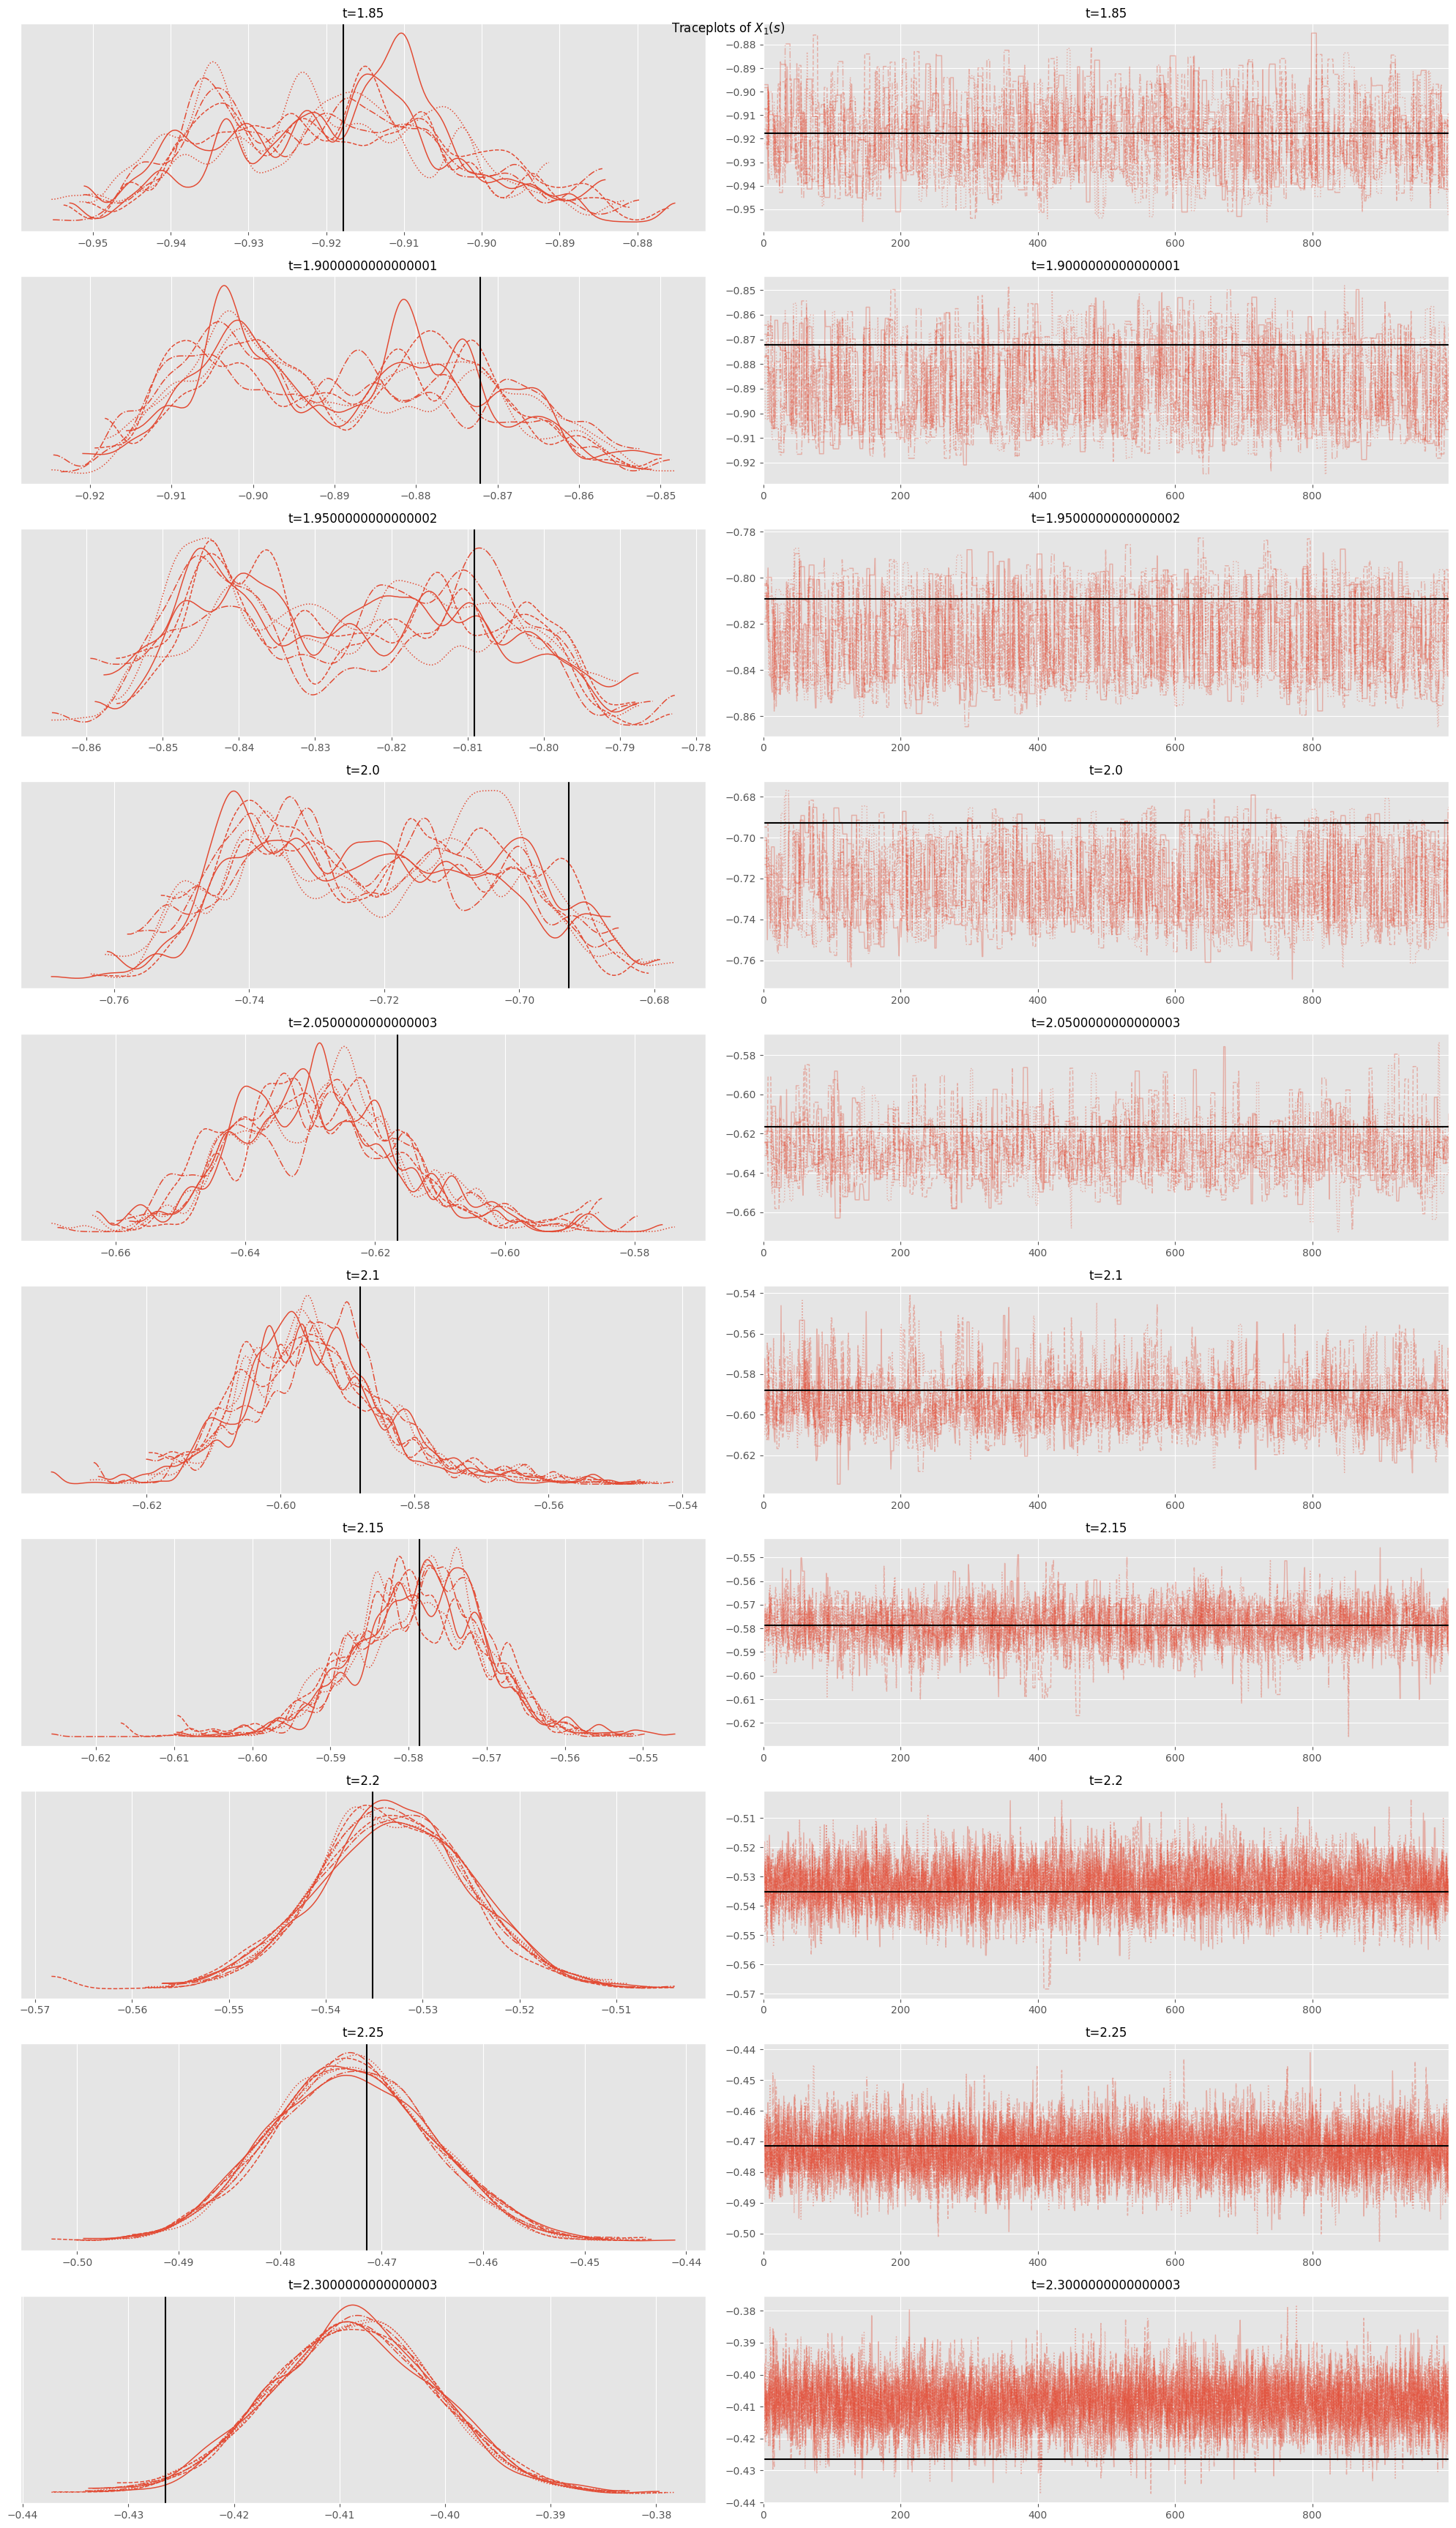

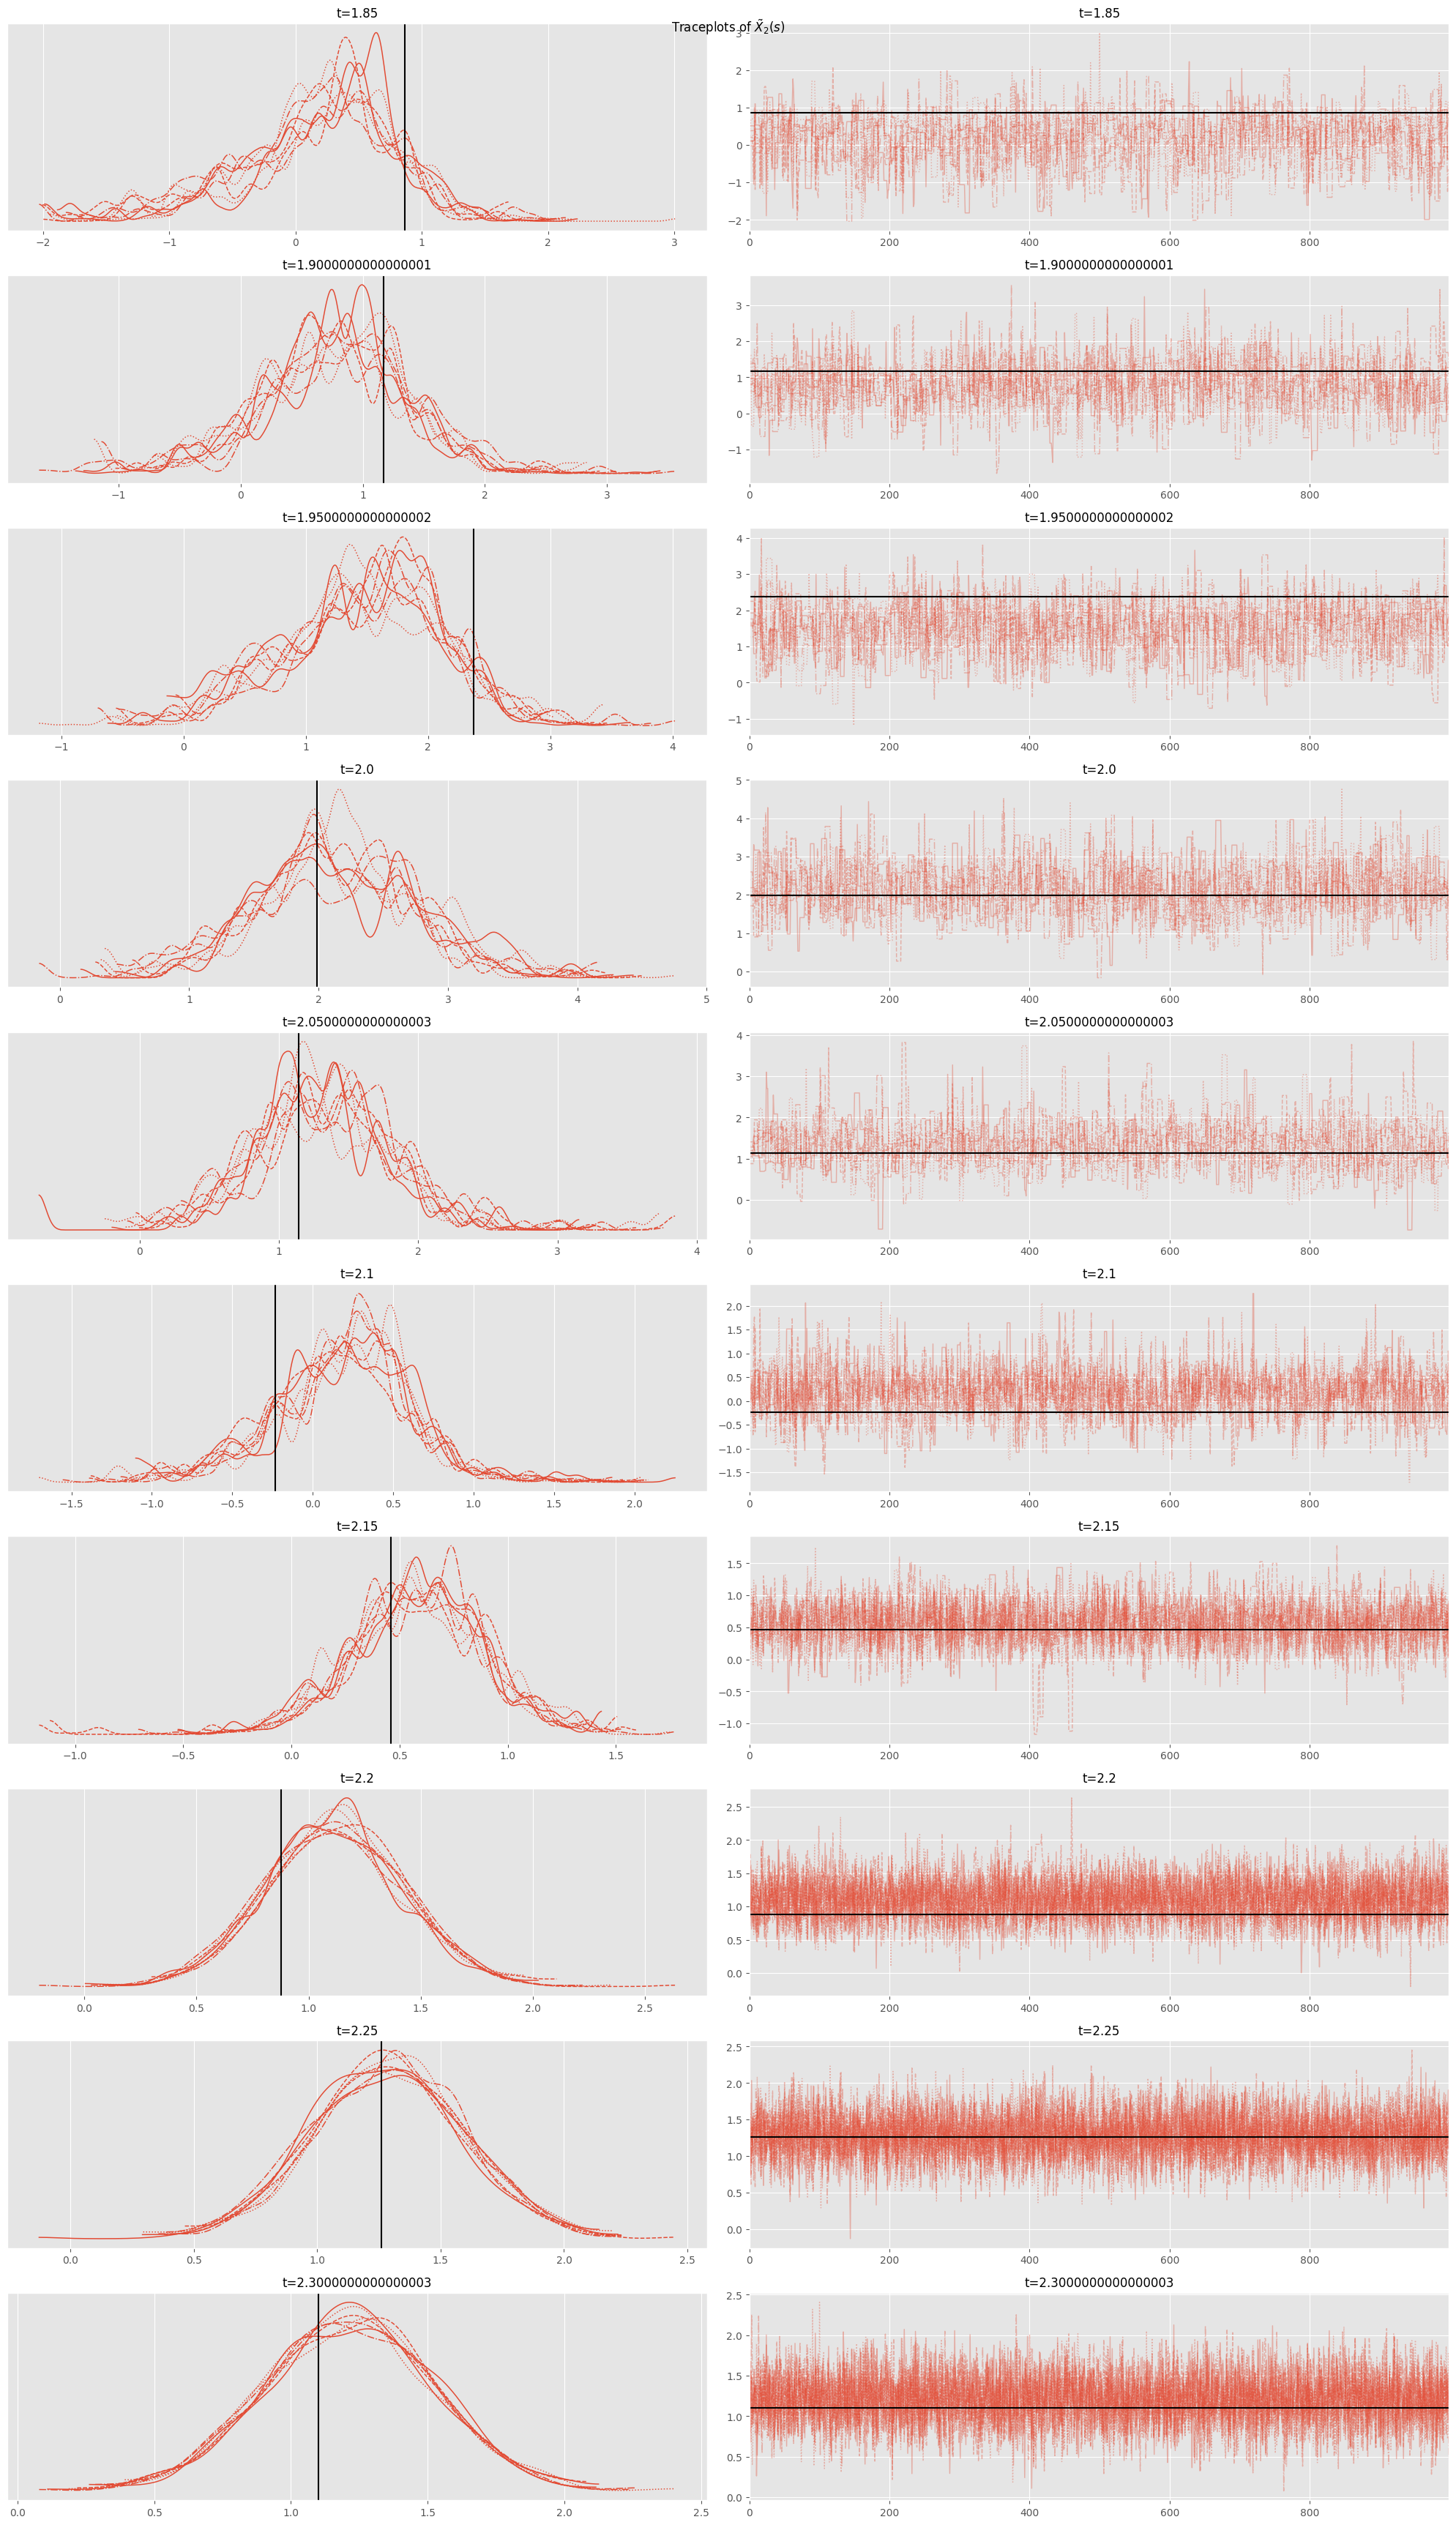

In [61]:
alg = 'BwG-iCSMC-BS'

title_end = [r'$X_1(s)$', r'$\tilde{X}_2(s)$']
# times = np.linspace(start=0., stop=5., num=11)[1:]
# true_values = np.stack([e_ts[10*(i+1) - 1, :] for i in range(10)])

time_arr = idata_dict[alg].posterior.coords['time']

times = time_arr.values[36:46:]
true_values = e_ts[36:46:, :]
for dimX in range(2):
    fig, axes = plt.subplots(len(times), 2, figsize=(20, 35))

    for i, time in enumerate(times):
        ax_row = axes[i]
        kde_ax, trace_ax = ax_row[0], ax_row[1]
        az.plot_trace(idata_dict[alg], var_names='x', coords={'dimX': [dimX], 'time': [time]}, axes=ax_row.reshape(1, 2))
        kde_ylim = kde_ax.get_ylim()
        kde_ax.vlines(true_values[i, dimX], ymin=kde_ylim[0], ymax=kde_ylim[1], linestyle='-', color='black', linewidth=1.5)
        kde_ax.set_ylim(kde_ylim)
        trace_xlim = trace_ax.get_xlim()
        trace_ax.hlines(true_values[i, dimX], xmin=trace_xlim[0], xmax=trace_xlim[1], linestyle='-', color='black', linewidth=1.5)
        trace_ax.set_xlim(trace_xlim)
        kde_ax.set_title(f't={time}', fontsize=12)
        trace_ax.set_title(f't={time}', fontsize=12)


    plt.suptitle('Traceplots of ' + title_end[dimX])
    plt.tight_layout()
    plt.show()

# R Hat Plots: Evaluates convergence based on similarity of multiple chains

As soon as we move away from the final time instance, the R-Hat for algorithms that do not involve the backward step deteriorate dramatically.

/Users/chris_stanton/code/particles_cdssm_workspace/particles-cdssm/venv/particles_cdssm/lib/python3.11/site-packages/arviz/stats/diagnostics.py:595: RuntimeWarning: invalid value encountered in sqrt
  rhat_value = np.sqrt(


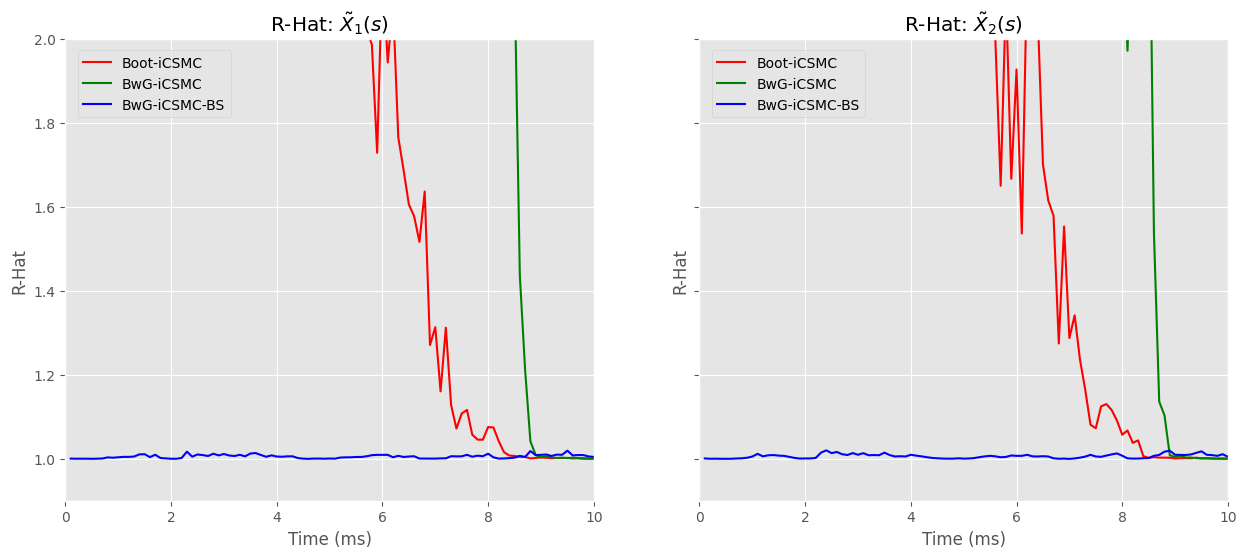

In [17]:
algs = [icsmc_bootstrap, icsmc_guided, icsmc_reparameterised]
labels = ['Boot-iCSMC', 'BwG-iCSMC', 'BwG-iCSMC-BS']
colors = ['red', 'green', 'blue']
titles = [r'$\tilde{X}_1(s)$', r'$\tilde{X}_2(s)$']

times = np.linspace(0., 10., num=101)[1:]
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

for i in range(3):
    for j in range(2):
        rhat = az.rhat(algs[i].posterior)
        rhat_values = rhat['x'].values
        axes[j].plot(times, rhat_values[:, j], color=colors[i], label=labels[i])
        axes[j].set(ylabel='R-Hat', xlabel='Time (ms)', title='R-Hat: ' + titles[j])
        axes[j].legend(loc='upper left', bbox_to_anchor=(0.01, 0.99))
        axes[j].set_xlim((0.0, 10.0))
        axes[j].set_ylim((0.9, 2.0))
plt.show()

# ESS Plots

## Full ESS: Uses data from all 8 chains in the calculation

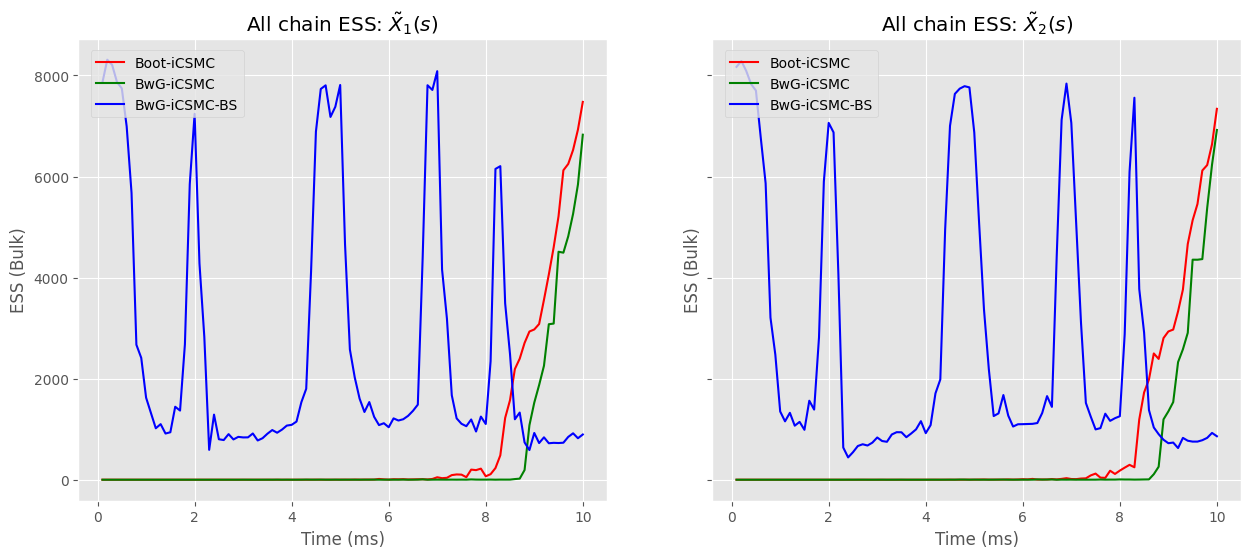

In [ ]:
algs = [icsmc_bootstrap, icsmc_guided, icsmc_reparameterised]
labels = ['Boot-iCSMC', 'BwG-iCSMC', 'BwG-iCSMC-BS']
colors = ['red', 'green', 'blue']
titles = [r'$\tilde{X}_1(s)$', r'$\tilde{X}_2(s)$']

times = np.linspace(0., S, num=T+1)[1:]
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

for i in range(3):
    for j in range(2):
        bulk_ess = az.ess(algs[i].posterior, method='bulk')
        bulk_ess_vals = bulk_ess['x'].values
        axes[j].plot(times, bulk_ess_vals[:, j], color=colors[i], label=labels[i])
        axes[j].set(ylabel='ESS (Bulk)', xlabel='Time (ms)', title='All chain ESS: ' + titles[j])
        axes[j].legend(loc='upper left', bbox_to_anchor=(0.01, 0.99))
# ax.set_xlim((9.5, 10.0))
plt.show()

## Partial ESS: Uses only the ESS in each individual chain for the calculation

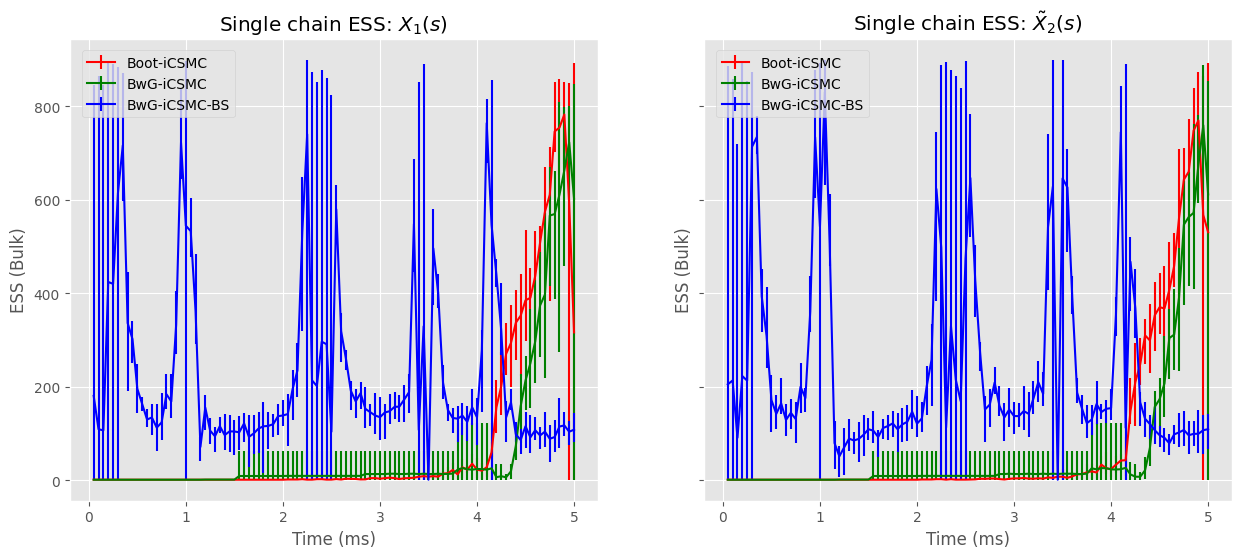

In [20]:
algs = [icsmc_bootstrap, icsmc_guided, icsmc_reparameterised]
labels = ['Boot-iCSMC', 'BwG-iCSMC', 'BwG-iCSMC-BS']
colors = ['red', 'green', 'blue']
titles = [r'${X}_1(s)$', r'$\tilde{X}_2(s)$']

times = np.linspace(0., S, num=T+1)[1:]
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

for i in range(3):
    bulk_ess_vals = []
    for k in range(8):
        bulk_ess_chain = az.ess(algs[i].posterior.sel(chain=[k]), method='bulk')
        bulk_ess_chain_vals = bulk_ess_chain['x'].values
        bulk_ess_vals.append(bulk_ess_chain_vals)
    bulk_ess_vals= np.stack(bulk_ess_vals, axis=2)
    bulk_ess_vals = np.where(bulk_ess_vals > 900., np.ones_like(bulk_ess_vals), bulk_ess_vals)
    avg_bulk_ess = bulk_ess_vals.mean(axis=2)
    max_bulk_ess = bulk_ess_vals.max(axis=2)
    min_bulk_ess = bulk_ess_vals.min(axis=2)
    yminerr = avg_bulk_ess - min_bulk_ess
    ymaxerr = max_bulk_ess - avg_bulk_ess
    for j in range(2):
        yerr = np.stack([yminerr[:, j], ymaxerr[:, j]], axis=0)
        axes[j].errorbar(times, avg_bulk_ess[:, j], yerr, color=colors[i], ecolor=colors[i], label=labels[i])
        axes[j].set(ylabel='ESS (Bulk)', xlabel='Time (ms)', title='Single chain ESS: ' + titles[j])
        axes[j].legend(loc='upper left', bbox_to_anchor=(0.01, 0.99))
# ax.set_xlim((9.5, 10.0))
plt.show()

# Update Rate Plots

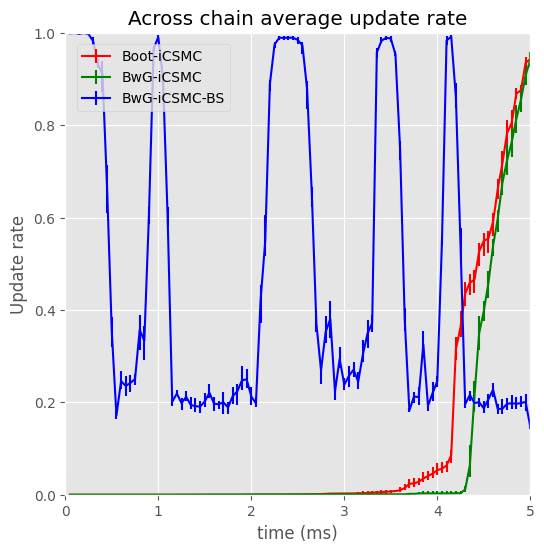

In [ ]:
algs = [icsmc_bootstrap, icsmc_guided, icsmc_reparameterised]
labels = ['Boot-iCSMC', 'BwG-iCSMC', 'BwG-iCSMC-BS']
colors = ['red', 'green', 'blue']

times = np.linspace(start=0., stop=S, num=T+1)[1:]

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

for i in range(3):
    X = algs[i].posterior['x'].values
    X_isupdated = 1.*(X[:, 1:] != X[:, :-1])
    X_update_rates = X_isupdated.mean(axis=1)[:, :, 0] # (8, 100)
    avg_update_rate = X_update_rates.mean(axis=0) # (100, )
    max_update_rate = X_update_rates.max(axis=0) # (100, )
    min_update_rate = X_update_rates.min(axis=0) # (100, )
    yerr = np.stack([avg_update_rate - min_update_rate, max_update_rate - avg_update_rate], axis=0)
    ax.errorbar(times, avg_update_rate, yerr=yerr, linestyle='-', color=colors[i], label=labels[i])

ax.set(xlabel='time (ms)', ylabel='Update rate', title='Across chain average update rate', xlim=(0., S), ylim=(0., 1.))
ax.legend(loc='upper left', bbox_to_anchor=(0.01, 0.99))
# plt.savefig('update_rate.png', dpi=300)
plt.show()

# What is happening under the hood with these algorithms? We run particle filters to find out:

In [24]:
import particles_cdssm.feynman_kac as sfk
import particles_cdssm.auxiliary_bridges as axb
from particles_cdssm import CDSSM_SMC

smc_kwargs = dict(N=500, store_history=True, num=50)

# This is the one that you ran in the first experiment:
cd_boot_fk = sfk.BootstrapDA(cdssm=cdssm, data=y)
cd_fk = sfk.BackwardGuidedDA(cdssm=cdssm, data=y)
                                    #   auxiliary_bridge_cls=axb.IntegratedNoDriftBrownianAuxBridge,
                                    #   end_pt_proposal_cls=axb.IntegratedDriftBrownianEndPointProposal)

fks = {'bootstrap': cd_boot_fk, 'backward_guided': cd_fk}

smcs = {key: CDSSM_SMC(fk, **smc_kwargs) for key, fk in fks.items()}

for key, alg in smcs.items():
    print(f'Running smc alg with fk {key}')
    alg.run()

Running smc alg with fk bootstrap
Running smc alg with fk backward_guided


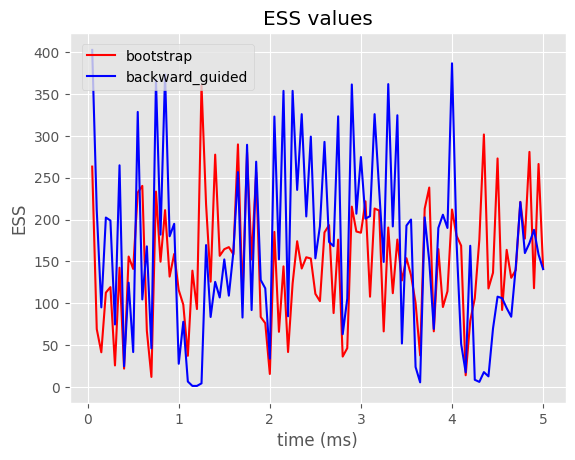

In [25]:
fig, ax = plt.subplots(1, 1)

colors = ['red', 'blue']

for i, (key, alg) in enumerate(smcs.items()):
    ax.plot(obs_times, alg.summaries.ESSs, color=colors[i], label=key)

ax.set(title='ESS values', xlabel='time (ms)', ylabel='ESS')
ax.legend(loc='upper left', bbox_to_anchor=(0.01, 0.99))

plt.show()

# Visualisation of the particle filter run:

## Single Step Visualisation

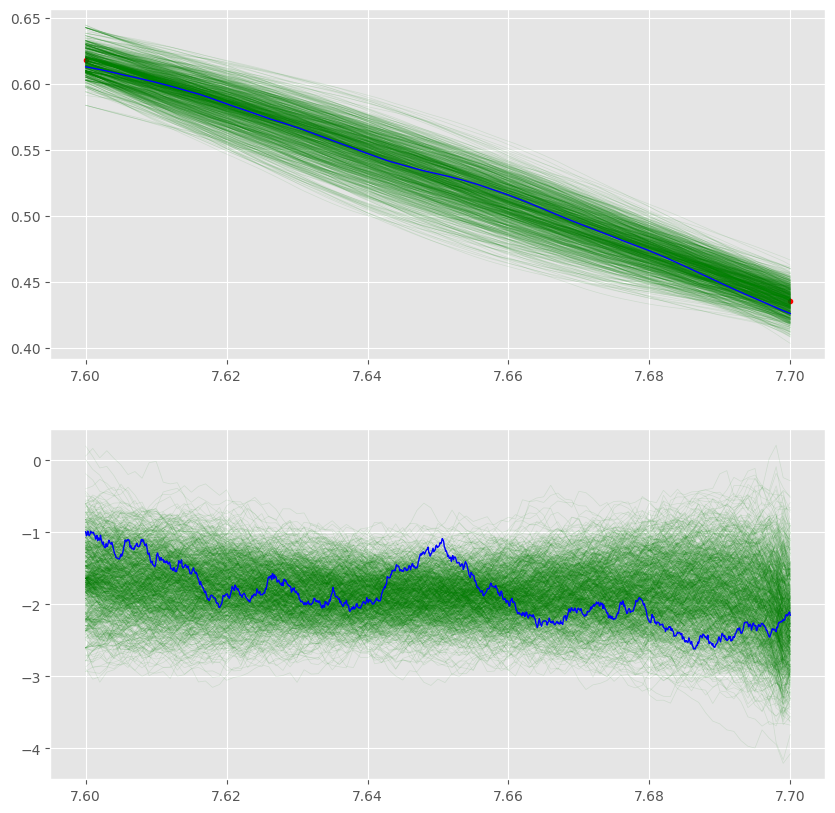

In [ ]:
num=100; N=1000
start_time = 7.6
end_time = start_time + cdssm.s_ts

times = np.linspace(start=start_time, stop=end_time, num=(num+1))
sim_times = np.linspace(start=start_time, stop=end_time, num=1001)

t = int(start_time / cdssm.s_ts)
smc = CDSSM_SMC(cd_fk, N=N, num=num, store_history=True)

for _ in range(t+1):
    smc.next()

Xp = smc.Xp; X = smc.X; W = smc.W

x_start = Xp[Xp.dtype.names[-1]] if Xp is not None else np.concatenate([cdssm.x0]*N, axis=0)
X_arr = np.stack([x_start] + [X[name] for name in X.dtype.names], axis=2)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

if t != 0:
    axes[0].plot([start_time, end_time], observations[t-1:(t+1)], 'o', color='red', markersize=3.0)
else:
    axes[0].plot([end_time], observations[0], 'o', color='red', markersize=3.0)

for i in range(2):
    axes[i].plot(times, X_arr[:, i].T, color='green', linewidth=0.5, linestyle='-', alpha=0.1, label='particles')
    axes[i].plot(sim_times, sde_paths[(1000)*t:((1000)*(t+1)+1), i].T, color='blue', linewidth=1.0, linestyle='-', label='')

# axes[0].set_xlabel()
plt.show()